In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D
import qutip as qt
from IPython.display import display, Math, Latex

# 设置全局字体为 Times New Roman
%config InlineBackend.figure_format = 'retina'
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams.update({"font.size": 18})

# 启用 LaTeX 渲染
plt.rcParams["text.usetex"] = True

# files = sorted(glob.glob("error_*.txt"))
#  N=2 偏离直线太多了
initial = "111"
N = 5
gamma = 0.1

# coefficients for extrapolation
b_list = np.array([-1 / 1152, 64 / 675, -729 / 1600, 117649 / 86400])

N_list = np.array([2, 3, 4, 5, 6])

r1_list = np.array([1, 2, 3, 7])

si_z = [
    qt.tensor([qt.qeye(2)] * i + [qt.sigmaz()] + [qt.qeye(2)] * (N - i - 1))
    for i in range(N)
]

O = sum([si_z[i] for i in range(N)]).full()
O_list = []

rho_superexact = np.load(
    f"../jobs/|{initial}>initial/gamma_{gamma}/rho_superexact_N_{N}_no_Euler.npy"
)
O_superexact = np.real(np.trace(O @ rho_superexact))

# record extrapolated observable values and max r  observable values for each scale
extrapolated_list = []
max_r_list = []

for scale in range(1, 11):
    O_list = []
    for r in r1_list:
        r = scale * r
        rho_Trotter = np.load(f"../jobs/|{initial}>initial/gamma_{gamma}/rho_N_{N}_r_{r}_no_Euler.npy")
        O_list.append(np.trace(O @ rho_Trotter))
        
    max_r_list.append(O_list[-1])    
    extrapolated_O = sum(b * O for b, O in zip(b_list, O_list))
    extrapolated_list.append(extrapolated_O)

print("Extrapolated values:", extrapolated_list)
print("Max r values:", max_r_list)

Extrapolated values: [(-4.7081153441653-1.166188074324154e-16j), (-4.708115308300265-5.057636142880997e-18j), (-4.708115365608368-1.877078837425629e-16j), (-4.708115359280102+1.058588664160648e-16j), (-4.708115348371982+8.999746115123697e-17j), (-4.708115345923432-8.67890415742181e-17j), (-4.70811534463474+2.6956444371318334e-17j), (-4.708115343996752-8.594409544183492e-17j), (-4.708115343794988+7.71714300205421e-18j), (-4.7081153437509835+4.2489897576018256e-17j)]
Max r values: [(-4.708246826461055-3.644600383880065e-17j), (-4.708148192887614+3.5246804639413765e-18j), (-4.708129948339336-1.4044087864898677e-16j), (-4.708123561551334+5.921966988507743e-17j), (-4.708120604029119+5.161523100334105e-17j), (-4.708118996767465-1.7399756095161288e-17j), (-4.708118027680788-2.7464461813212412e-17j), (-4.708117398741647-4.949662980718458e-17j), (-4.708116967565878-3.3459336999803886e-18j), (-4.708116659164371+1.1389092256955248e-17j)]


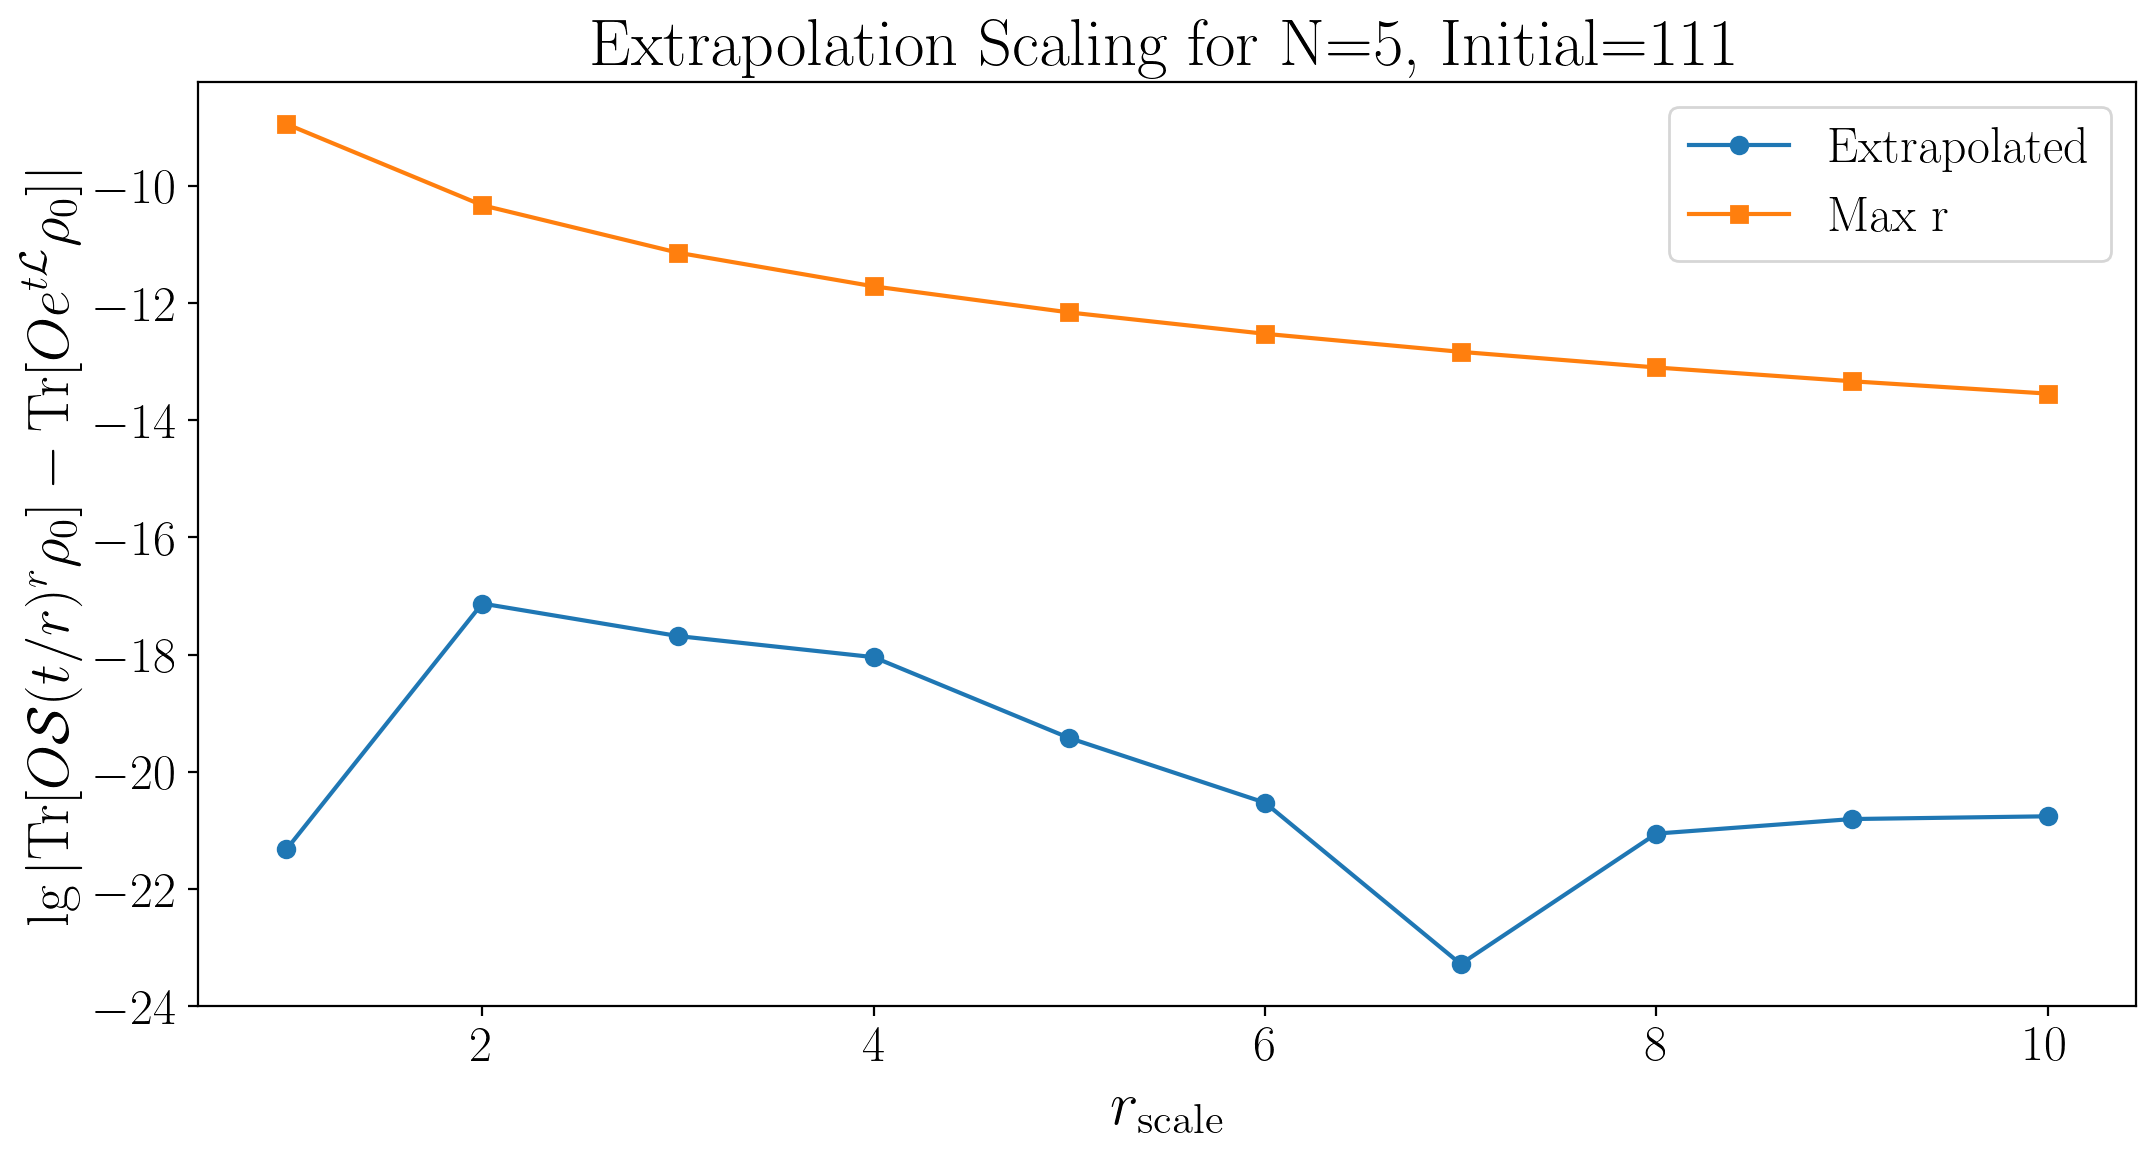

In [3]:
fig, ax = plt.subplots(figsize=(12.5, 6))
ax.plot(range(1, 11), np.log(np.abs(extrapolated_list - O_superexact)), marker="o", label="Extrapolated")
ax.plot(range(1, 11), np.log(np.abs(max_r_list - O_superexact)), marker="s", label="Max r")

ax.set_xlabel("$r_{\mathrm{scale}}$", fontsize=22)
ax.set_ylabel(
    "$\lg|\mathrm{Tr}[O\mathcal{S}(t/r)^r\\rho_0]-\mathrm{Tr}[Oe^{t\mathcal{L}}\\rho_0]|$",
    fontsize=21,
)
ax.legend()
ax.set_title(f"Extrapolation Scaling for N={N}, Initial={initial}", fontsize=24)

plt.savefig(f"extrapolation-{N}-{initial}_scaling.pdf")
plt.show()